In [21]:
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier


# ==========================================
# 1. Load Placement Prediction Dataset
# ==========================================
df = pd.read_csv("/content/DT_Placement.csv")

print("Dataset:")
print(df)

print("\nDataset Information:")
print(df.info())

Dataset:
     ID  CGPA  Internships Backlogs  Aptitude Placed
0    S1   8.6            2       No        73    Yes
1    S2   9.4            2       No        76    Yes
2    S3   9.0            2       No        81    Yes
3    S4   5.2            0      Yes        48     No
4    S5   5.3            0      Yes        44     No
5    S6   5.0            1       No        83     No
6    S7   6.2            1      Yes        63     No
7    S8   6.2            0      Yes        52    Yes
8    S9   8.7            2      Yes        77    Yes
9   S10   7.5            1       No        70    Yes
10  S11   6.7            1       No        96    Yes
11  S12   7.5            1       No        84    Yes
12  S13   6.8            0      Yes        48     No
13  S14   6.8            0       No        73     No

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14 entries, 0 to 13
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       ------------

In [22]:
df["Backlogs"] = df["Backlogs"].map({
    "No": 0,
    "Yes": 1
})

# Placed: No = 0, Yes = 1
df["Placed"] = df["Placed"].map({
    "No": 0,
    "Yes": 1
})

In [23]:
X = df.drop(["ID", "Placed"], axis=1)

y = df["Placed"]


print("\nFeatures:")
print(X)

print("\nTarget:")
print(y)


Features:
    CGPA  Internships  Backlogs  Aptitude
0    8.6            2         0        73
1    9.4            2         0        76
2    9.0            2         0        81
3    5.2            0         1        48
4    5.3            0         1        44
5    5.0            1         0        83
6    6.2            1         1        63
7    6.2            0         1        52
8    8.7            2         1        77
9    7.5            1         0        70
10   6.7            1         0        96
11   7.5            1         0        84
12   6.8            0         1        48
13   6.8            0         0        73

Target:
0     1
1     1
2     1
3     0
4     0
5     0
6     0
7     1
8     1
9     1
10    1
11    1
12    0
13    0
Name: Placed, dtype: int64


In [4]:
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)


print("\nTraining samples:", len(X_train))
print("Validation samples:", len(X_val))


Training samples: 9
Validation samples: 5


In [24]:
def boosting_benchmark(X_train, y_train, X_val, y_val):

    models = {

        "AdaBoost": AdaBoostClassifier(
            n_estimators=100,
            learning_rate=0.1,
            random_state=42
        ),

        "GBC": GradientBoostingClassifier(
            n_estimators=100,
            learning_rate=0.1,
            max_depth=3,
            random_state=42
        ),

        "XGB": XGBClassifier(
            n_estimators=100,
            learning_rate=0.1,
            max_depth=3,
            random_state=42,
            eval_metric="logloss"
        ),

        "LGB": LGBMClassifier(
            n_estimators=100,
            learning_rate=0.1,
            max_depth=3,
            random_state=42,
            verbosity=-1
        )
    }

    results = []

    for name, model in models.items():

        # Train model
        model.fit(X_train, y_train)

        # Predictions
        train_pred = model.predict(X_train)
        val_pred = model.predict(X_val)

        # Accuracy
        train_accuracy = accuracy_score(
            y_train,
            train_pred
        )

        val_accuracy = accuracy_score(
            y_val,
            val_pred
        )

        results.append({
            "model": name,
            "train_accuracy": train_accuracy,
            "val_accuracy": val_accuracy
        })

    # Convert to DataFrame
    results_df = pd.DataFrame(results)

    # Sort by validation accuracy
    results_df = results_df.sort_values(
        by="val_accuracy",
        ascending=False
    ).reset_index(drop=True)

    return results_df

In [25]:
results = boosting_benchmark(
    X_train,
    y_train,
    X_val,
    y_val
)

In [26]:
print("\nBoosting Benchmark Results:")
print(results)


Boosting Benchmark Results:
      model  train_accuracy  val_accuracy
0  AdaBoost        1.000000           0.8
1       GBC        1.000000           0.6
2       XGB        0.555556           0.6
3       LGB        0.555556           0.6


In [27]:
import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

import shap

In [28]:
df = pd.read_csv("/content/DT_Placement.csv")

print("Dataset:")
print(df)

Dataset:
     ID  CGPA  Internships Backlogs  Aptitude Placed
0    S1   8.6            2       No        73    Yes
1    S2   9.4            2       No        76    Yes
2    S3   9.0            2       No        81    Yes
3    S4   5.2            0      Yes        48     No
4    S5   5.3            0      Yes        44     No
5    S6   5.0            1       No        83     No
6    S7   6.2            1      Yes        63     No
7    S8   6.2            0      Yes        52    Yes
8    S9   8.7            2      Yes        77    Yes
9   S10   7.5            1       No        70    Yes
10  S11   6.7            1       No        96    Yes
11  S12   7.5            1       No        84    Yes
12  S13   6.8            0      Yes        48     No
13  S14   6.8            0       No        73     No


In [29]:
df["Backlogs"] = df["Backlogs"].map({
    "No": 0,
    "Yes": 1
})

df["Placed"] = df["Placed"].map({
    "No": 0,
    "Yes": 1
})

In [30]:
X = df.drop(["ID", "Placed"], axis=1)
y = df["Placed"]

print("\nFeatures:")
print(X)

print("\nTarget:")
print(y)


Features:
    CGPA  Internships  Backlogs  Aptitude
0    8.6            2         0        73
1    9.4            2         0        76
2    9.0            2         0        81
3    5.2            0         1        48
4    5.3            0         1        44
5    5.0            1         0        83
6    6.2            1         1        63
7    6.2            0         1        52
8    8.7            2         1        77
9    7.5            1         0        70
10   6.7            1         0        96
11   7.5            1         0        84
12   6.8            0         1        48
13   6.8            0         0        73

Target:
0     1
1     1
2     1
3     0
4     0
5     0
6     0
7     1
8     1
9     1
10    1
11    1
12    0
13    0
Name: Placed, dtype: int64


In [31]:
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

print("\nTraining samples:", len(X_train))
print("Validation samples:", len(X_val))


Training samples: 9
Validation samples: 5


In [32]:
ada = AdaBoostClassifier(
    n_estimators=10,
    learning_rate=0.5,
    random_state=42
)

# Initial equal weights
initial_weights = np.ones(len(X_train)) / len(X_train)

print("\nInitial AdaBoost sample weights:")
print(initial_weights)

ada.fit(X_train, y_train)

# Prediction
ada_pred = ada.predict(X_val)

print("\nAdaBoost Validation Accuracy:",
      accuracy_score(y_val, ada_pred))


Initial AdaBoost sample weights:
[0.11111111 0.11111111 0.11111111 0.11111111 0.11111111 0.11111111
 0.11111111 0.11111111 0.11111111]

AdaBoost Validation Accuracy: 0.6


In [33]:
print("\nAdaBoost estimator weights:")

for i, weight in enumerate(ada.estimator_weights_):
    print(f"Estimator {i + 1}: {weight:.4f}")


AdaBoost estimator weights:
Estimator 1: 1.0397
Estimator 2: 0.7424
Estimator 3: 0.6414
Estimator 4: 0.6959
Estimator 5: 0.4541
Estimator 6: 0.4478
Estimator 7: 0.4812
Estimator 8: 0.4598
Estimator 9: 0.4587
Estimator 10: 0.3498


In [34]:
xgb = XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=3,
    random_state=42,
    eval_metric="logloss",
    early_stopping_rounds=20
)

xgb.fit(
    X_train,
    y_train,
    eval_set=[(X_val, y_val)],
    verbose=False
)

xgb_pred = xgb.predict(X_val)

print("\nXGBoost Validation Accuracy:",
      accuracy_score(y_val, xgb_pred))

print("Best XGBoost iteration:",
      xgb.best_iteration)


XGBoost Validation Accuracy: 0.6
Best XGBoost iteration: 0


In [35]:
lgb = LGBMClassifier(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=3,
    random_state=42,
    verbosity=-1
)

start_time = time.perf_counter()

lgb.fit(X_train, y_train)

end_time = time.perf_counter()

lgb_time = end_time - start_time

lgb_pred = lgb.predict(X_val)

print("\nLightGBM Validation Accuracy:",
      accuracy_score(y_val, lgb_pred))

print(f"LightGBM Training Time: {lgb_time:.6f} seconds")


LightGBM Validation Accuracy: 0.6
LightGBM Training Time: 0.011099 seconds


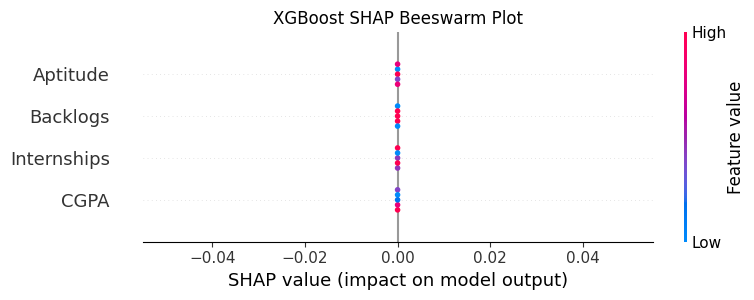

In [36]:

explainer = shap.TreeExplainer(xgb)

shap_values = explainer.shap_values(X_val)

plt.figure(figsize=(8, 5))

shap.summary_plot(
    shap_values,
    X_val,
    plot_type="dot",
    show=False
)

plt.title("XGBoost SHAP Beeswarm Plot")
plt.tight_layout()
plt.show()

In [37]:
def boosting_benchmark(X_train, y_train, X_val, y_val):

    models = {

        "AdaBoost": AdaBoostClassifier(
            n_estimators=100,
            learning_rate=0.1,
            random_state=42
        ),

        "GBC": GradientBoostingClassifier(
            n_estimators=100,
            learning_rate=0.1,
            max_depth=3,
            random_state=42
        ),

        "XGB": XGBClassifier(
            n_estimators=100,
            learning_rate=0.1,
            max_depth=3,
            random_state=42,
            eval_metric="logloss"
        ),

        "LGB": LGBMClassifier(
            n_estimators=100,
            learning_rate=0.1,
            max_depth=3,
            random_state=42,
            verbosity=-1
        )
    }

    results = []

    for name, model in models.items():

        start_time = time.perf_counter()

        model.fit(X_train, y_train)

        end_time = time.perf_counter()

        train_time = end_time - start_time

        train_pred = model.predict(X_train)
        val_pred = model.predict(X_val)

        train_accuracy = accuracy_score(
            y_train,
            train_pred
        )

        val_accuracy = accuracy_score(
            y_val,
            val_pred
        )

        results.append({
            "model": name,
            "train_accuracy": train_accuracy,
            "val_accuracy": val_accuracy,
            "training_time_sec": train_time
        })

    results_df = pd.DataFrame(results)

    # Sort by validation accuracy
    results_df = results_df.sort_values(
        by="val_accuracy",
        ascending=False
    ).reset_index(drop=True)

    return results_df

In [38]:
results = boosting_benchmark(
    X_train,
    y_train,
    X_val,
    y_val
)

print("\n==========================================")
print("BOOSTING BENCHMARK RESULTS")
print("==========================================")

print(results)


BOOSTING BENCHMARK RESULTS
      model  train_accuracy  val_accuracy  training_time_sec
0  AdaBoost        1.000000           0.8           0.199271
1       GBC        1.000000           0.6           0.108164
2       XGB        0.555556           0.6           0.023634
3       LGB        0.555556           0.6           0.006262


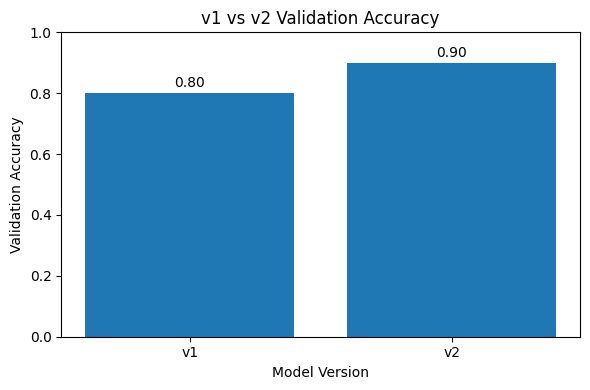

In [39]:
v1_accuracy = 0.80
v2_accuracy = 0.90

versions = ["v1", "v2"]
accuracies = [v1_accuracy, v2_accuracy]

plt.figure(figsize=(6, 4))

plt.bar(
    versions,
    accuracies
)

plt.ylabel("Validation Accuracy")
plt.xlabel("Model Version")
plt.title("v1 vs v2 Validation Accuracy")

plt.ylim(0, 1)

for i, value in enumerate(accuracies):
    plt.text(
        i,
        value + 0.02,
        f"{value:.2f}",
        ha="center"
    )

plt.tight_layout()
plt.show()